# North Qoroq ca. 1275 Ma paleomagnetic pole

Site-mean directions for the North Qoroq intrusion are compiled from Piper (1992), Table 3, in `../data/1275_North_Qoroq/`. This notebook recalculates the site-VGP Fisher pole and compares it with the Piper/Evans direction-derived pole.

In [1]:
import pole_tools as pt
import pmagpy.ipmag as ipmag
import pmagpy.pmag as pmag
import pandas as pd
import matplotlib.pyplot as plt

Laurentia_poles = pt.get_Laurentia_poles()
Laurentia_stricto_poles = pt.get_Laurentia_stricto_poles()

%config InlineBackend.figure_format='retina'
%matplotlib inline

## Site-level data

Twelve included site means are loaded from the study-specific MagIC contribution. Piper (1992) marks site 25 and component 37(a) as excluded; those are not included here. VGPs are computed at 61.2 N, 314.6 E.

In [2]:
sites = pd.read_csv('../data/1275_North_Qoroq/sites.txt', sep='	', skiprows=1)
sites = sites[sites['result_quality'] == 'g'].reset_index(drop=True)
study_lat, study_lon = 61.2, 314.6
numeric_cols = ['dir_dec', 'dir_inc', 'dir_k', 'dir_alpha95', 'dir_n_samples']
for col in numeric_cols:
    sites[col] = pd.to_numeric(sites[col], errors='coerce')

vgp_lon, vgp_lat, vgp_dp, vgp_dm = [], [], [], []
for _, r in sites.iterrows():
    plon, plat, dp, dm = pmag.dia_vgp(r['dir_dec'], r['dir_inc'], r['dir_alpha95'], study_lat, study_lon)
    vgp_lon.append(round(plon % 360, 1))
    vgp_lat.append(round(plat, 1))
    vgp_dp.append(dp)
    vgp_dm.append(dm)

sites = sites.assign(vgp_lon=vgp_lon, vgp_lat=vgp_lat, vgp_dp=vgp_dp, vgp_dm=vgp_dm)

print(f'{len(sites)} North Qoroq sites; {int(sites["dir_n_samples"].sum())} samples')
sites[['site', 'dir_dec', 'dir_inc', 'dir_k', 'dir_alpha95', 'dir_n_samples', 'vgp_lat', 'vgp_lon']]

12 North Qoroq sites; 65 samples


,site,dir_dec,dir_inc,dir_k,dir_alpha95,dir_n_samples,vgp_lat,vgp_lon
0,16,293,4,20,16,6,12.6,205.1
1,17,308,4,9,27,5,19.1,191.0
2,22,90,-15,23,26,3,-6.7,48.3
3,23,285,4,15,21,5,8.9,212.3
4,27,319,-4,14,25,4,19.4,178.6
5,29,268,10,34,13,5,3.5,228.8
6,31,313,-3,22,2,8,17.8,184.8
7,32,313,-1,74,9,5,18.7,185.1
8,34,312,5,30,12,6,21.1,187.3
9,36,300,24,17,17,6,25.2,203.7


## Mean direction

Piper (1992) identifies a reversal at site 22, so the direction mean is calculated after polarity unification.

Dec: 295.8  Inc: 3.2
Number of directions in mean (n): 12
Angular radius of 95% confidence (a_95): 11.7
Precision parameter (k) estimate: 14.7
Piper (1992) group mean direction: 295.7/2.5, alpha95 12
direction-derived pole: 13.6 N / 202.4 E, dp/dm 5.9/11.7, geometric A95 8.3
Piper (1992) / Evans et al. (2021): 13.2 N / 202.6 E, dp/dm 5.9/11.7, A95 8.3


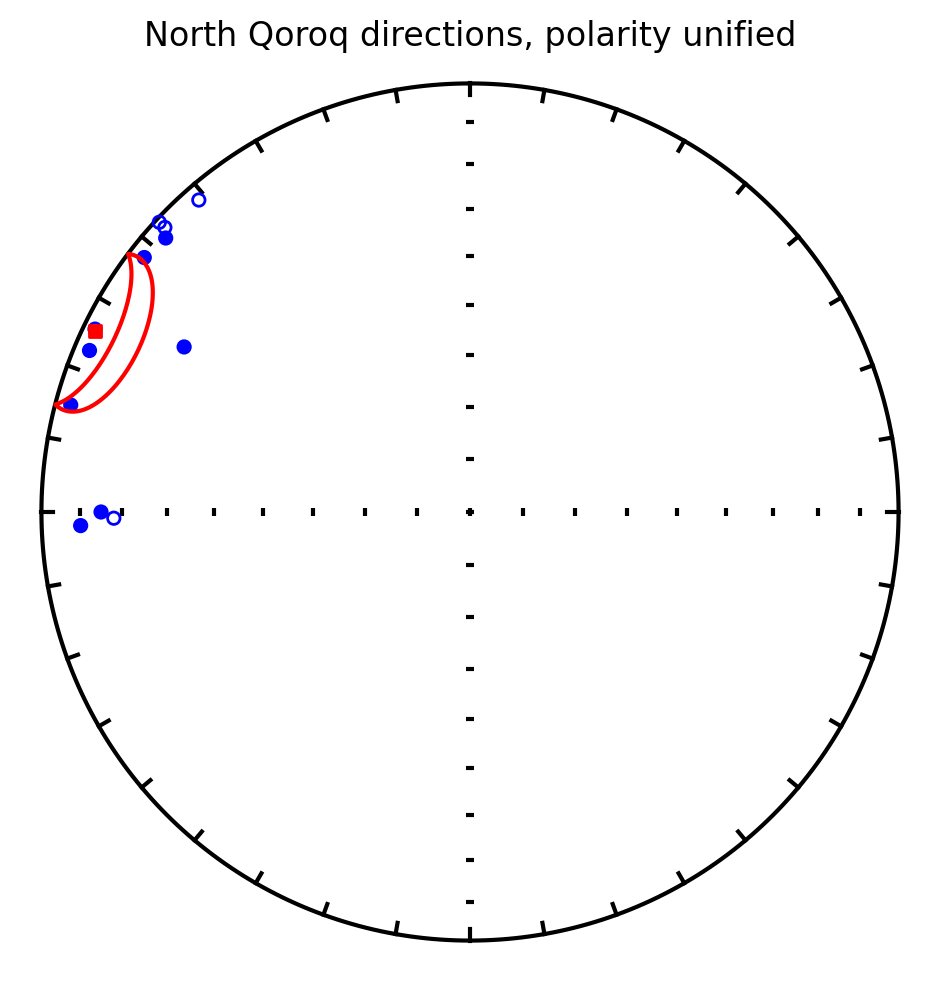

In [3]:
dir_block, dir_mean = pt.compute_mean_direction(sites, unify_polarity=True)
ipmag.print_direction_mean(dir_mean)
print('Piper (1992) group mean direction: 295.7/2.5, alpha95 12')

plon_dir, plat_dir, dp_dir, dm_dir = pmag.dia_vgp(dir_mean['dec'], dir_mean['inc'], dir_mean['alpha95'], study_lat, study_lon)
dir_pole = {'dec': plon_dir % 360, 'inc': plat_dir, 'dp': dp_dir, 'dm': dm_dir, 'alpha95': (dp_dir * dm_dir) ** 0.5}
print(f"direction-derived pole: {dir_pole['inc']:.1f} N / {dir_pole['dec']:.1f} E, dp/dm {dir_pole['dp']:.1f}/{dir_pole['dm']:.1f}, geometric A95 {dir_pole['alpha95']:.1f}")
print('Piper (1992) / Evans et al. (2021): 13.2 N / 202.6 E, dp/dm 5.9/11.7, A95 8.3')

ipmag.plot_net()
ipmag.plot_di(di_block=dir_block, color='blue', marker='o')
ipmag.plot_di_mean(dir_mean['dec'], dir_mean['inc'], dir_mean['alpha95'], color='red', marker='s')
plt.title('North Qoroq directions, polarity unified')
plt.show()

## Mean pole from site VGPs

The recalculated site-VGP Fisher pole uses the same polarity unification. Its position is close to Piper's direction-derived pole; the circular A95 is larger because it is calculated directly from the site VGP population.

Plon: 202.5  Plat: 13.5
Number of directions in mean (n): 12
Angular radius of 95% confidence (A_95): 10.6
Precision parameter (k) estimate: 17.6
Piper (1992) / Evans et al. (2021) direction-derived pole: 13.2 N / 202.6 E, A95 8.3


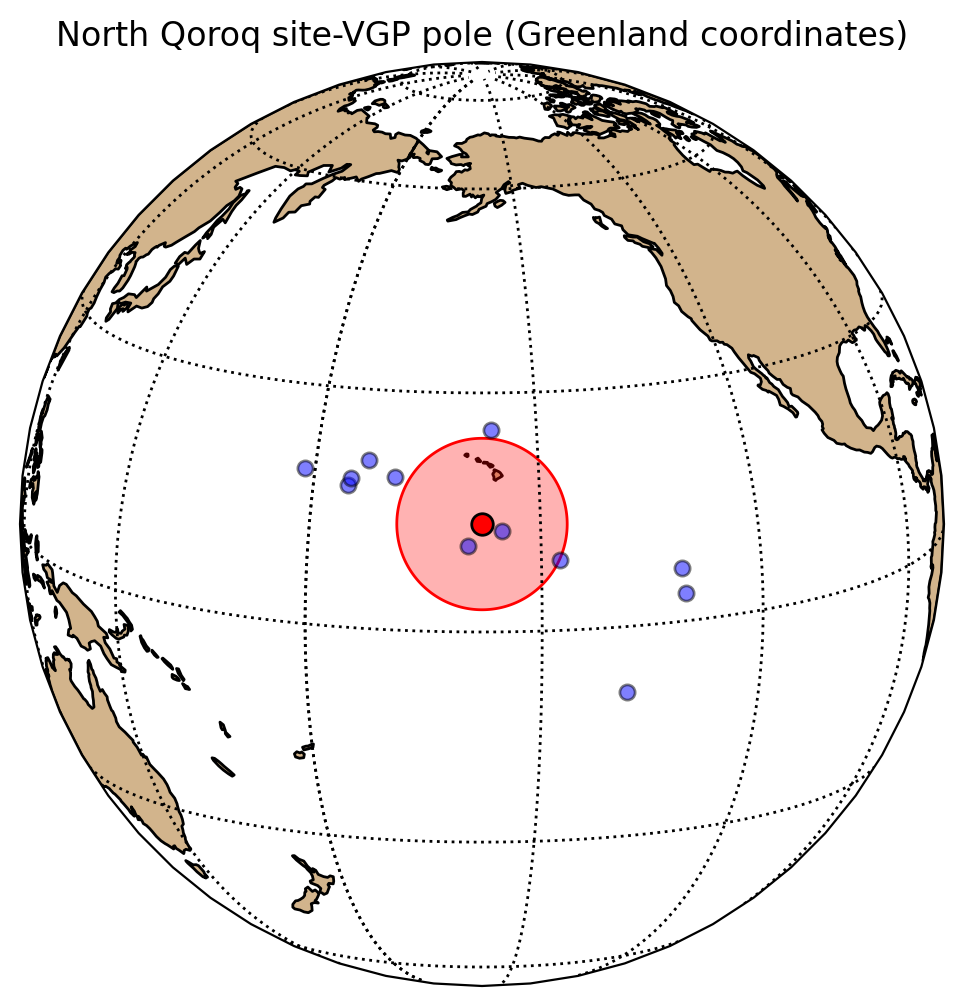

In [4]:
vgp_block, pole_mean = pt.compute_mean_pole(sites, unify_polarity=True)
ipmag.print_pole_mean(pole_mean)
print('Piper (1992) / Evans et al. (2021) direction-derived pole: 13.2 N / 202.6 E, A95 8.3')
_ = pt.plot_vgps_and_pole(vgp_block, pole_mean, central_longitude=pole_mean['dec'],
                          central_latitude=pole_mean['inc'], figsize=(6, 6))
plt.title('North Qoroq site-VGP pole (Greenland coordinates)')
plt.show()

## Paleosecular variation and R2

In [5]:
r2_result = pt.assess_R2(sites, pole_mean)
print()
pt.Deenen_test(pole_mean['n'], pole_mean['alpha95'])
_ = pt.plot_Deenen_test(pole_mean)

R2 assessment (Meert et al., 2020):
  (a) two demag methods (AF + thermal)  [advisory, from method_codes]: no
  (b) PCA / great-circle component analysis  [advisory, from method_codes]: no
      note: method codes are inconsistently applied; confirm (a)/(b) against the source publication.
  (c) adequate PSV sampling [scored]:
        N = 65 samples (>= 25): PASS
        K = 17.6 (10-70): PASS
        B = 12 sites (>= 8): PASS
        min 3 samples/site (>= 3): PASS
        A95 = 10.6 in Deenen envelope [4.4, 17.1]: PASS
  => R2 (from sub-criterion c) = 1

A_95 of 10.6 passes Deenen et al. (2011) criteria of being between 4.4 and 17.1 for this number of sites


## Laurentia reference frame

unrotated (present-day Greenland frame): 13.5 N / 202.5 E, A95 10.6
rotated into the Laurentia frame:        17.2 N / 190.8 E, A95 10.6


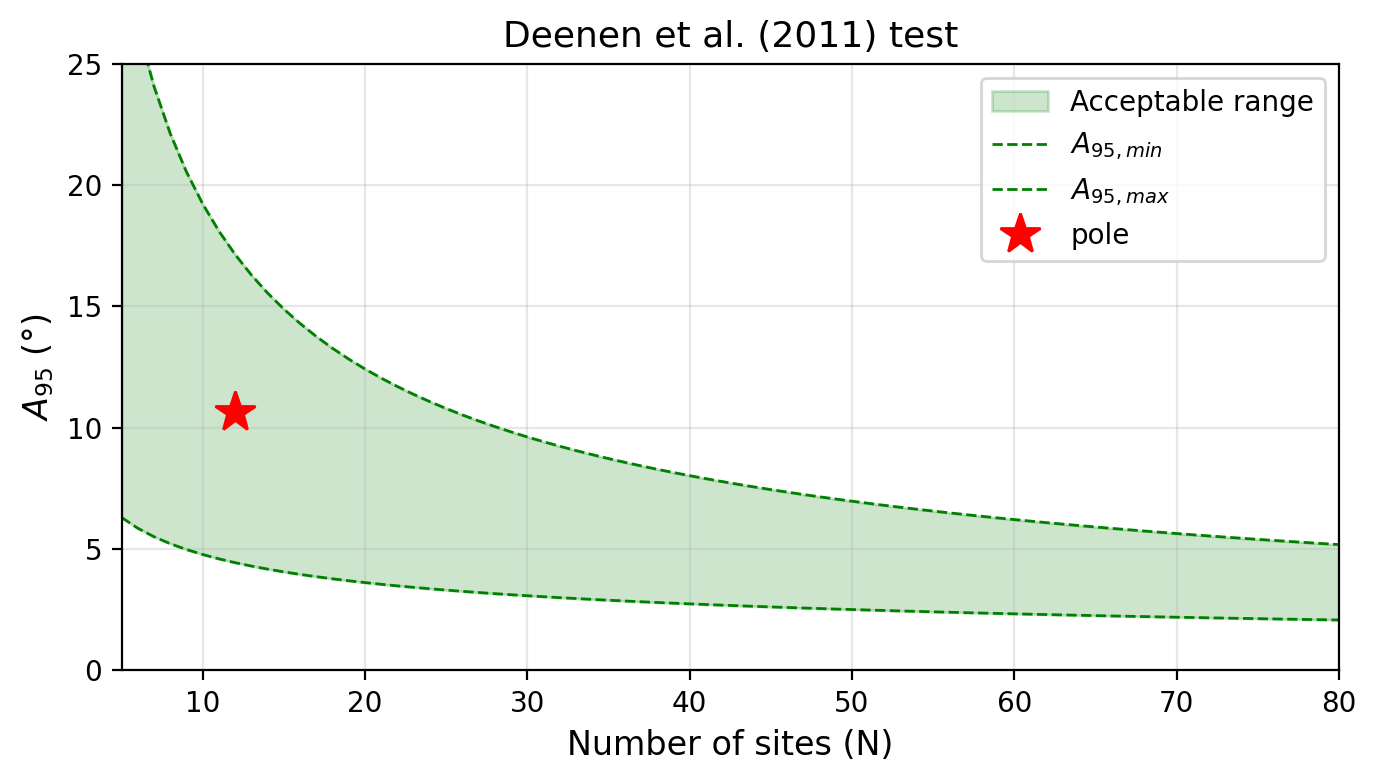

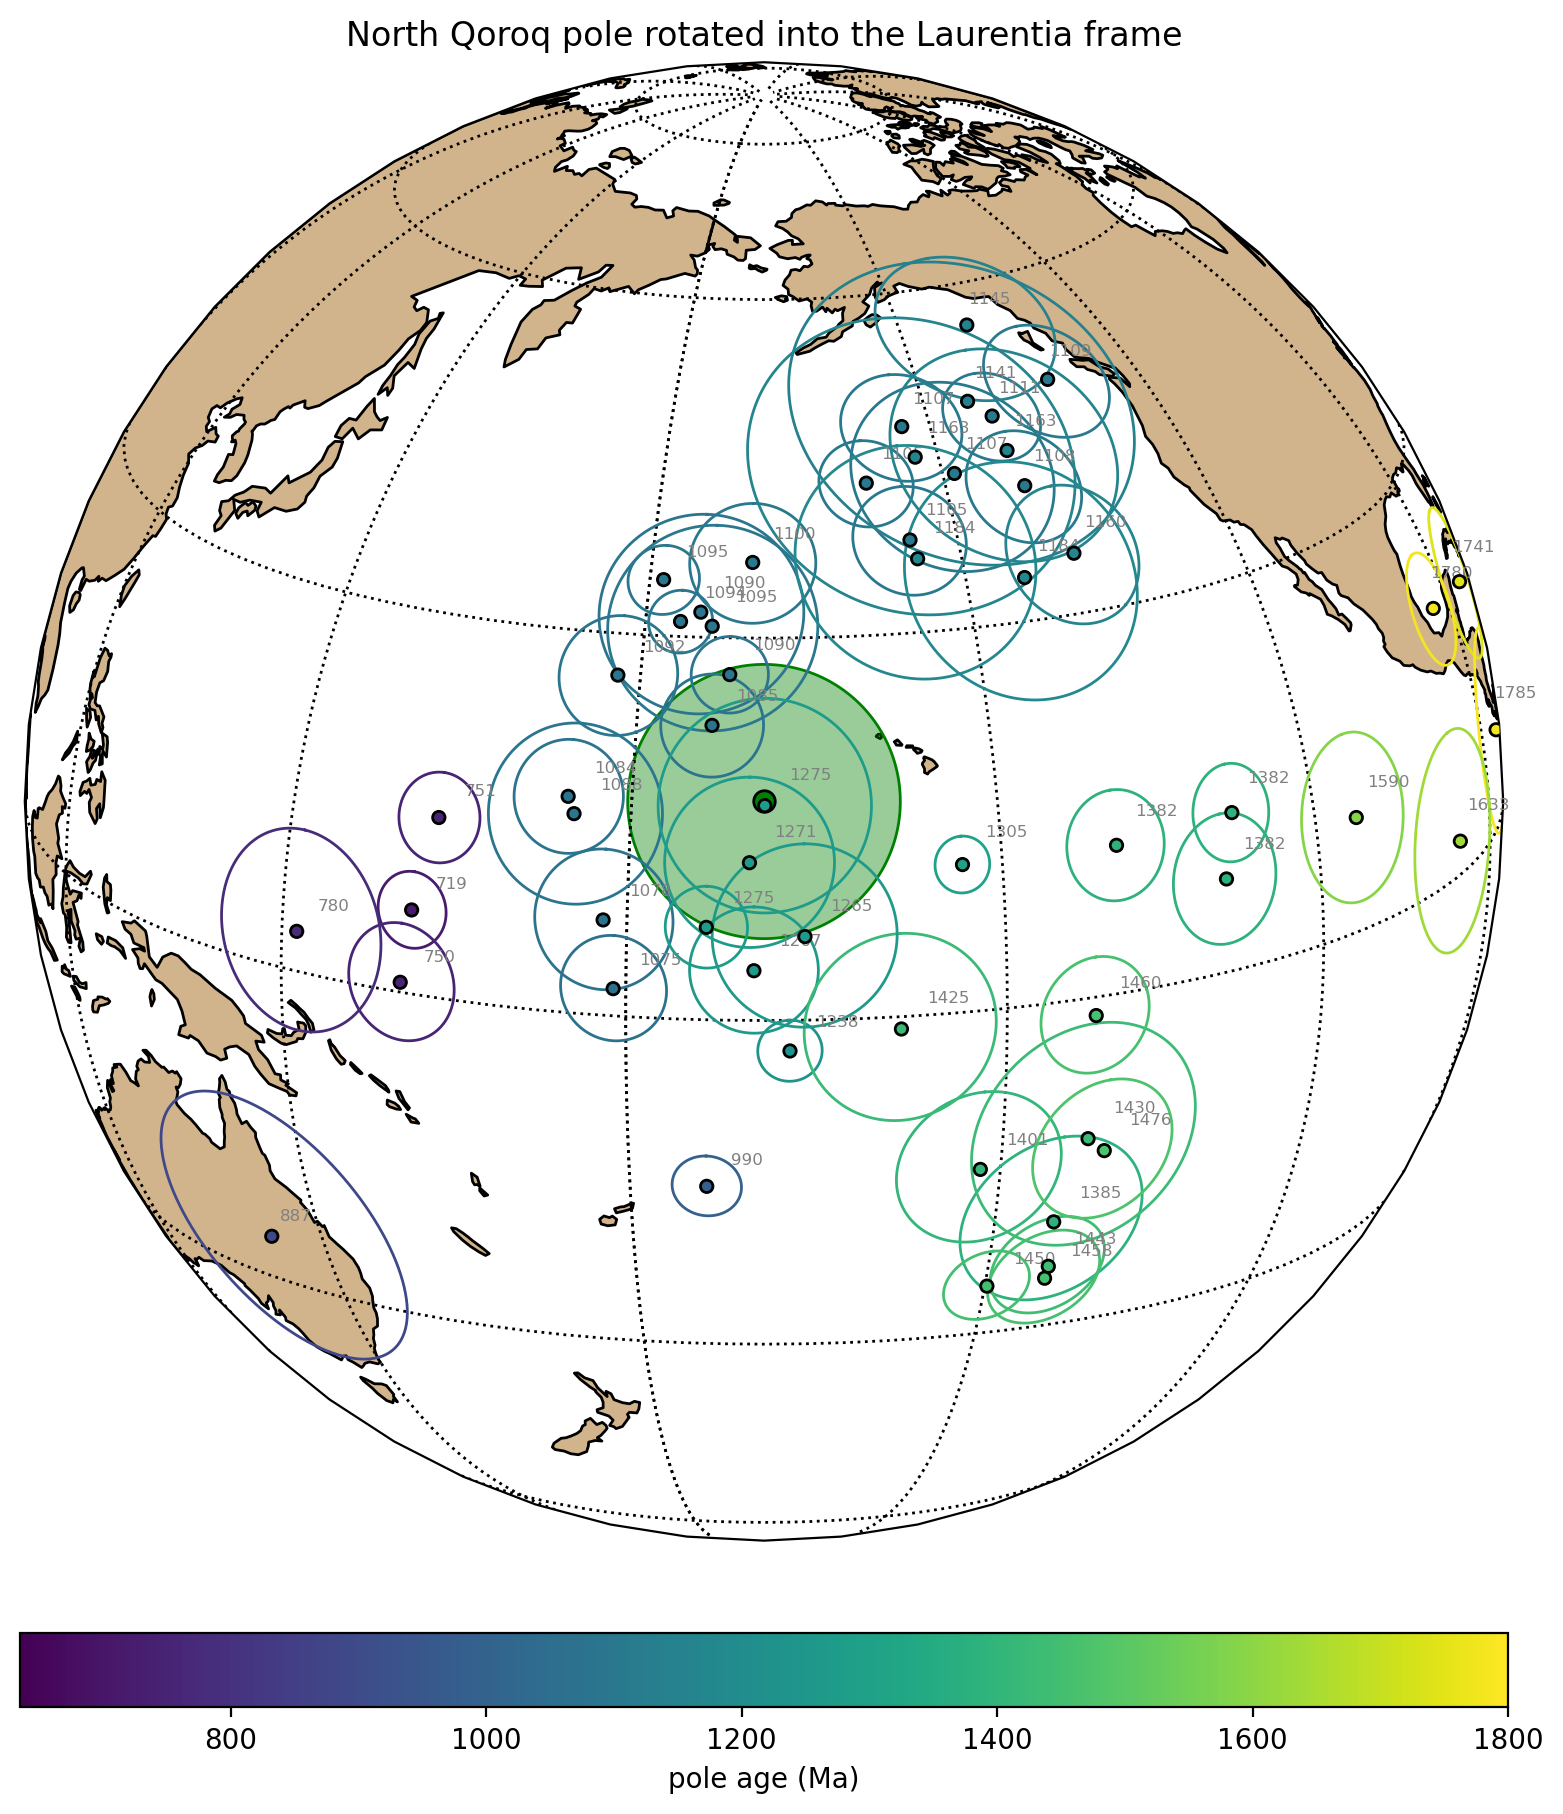

In [6]:
EULER_GREENLAND = pt.TERRANE_EULER_POLES['Laurentia-Greenland']
_rlat, _rlon = pmag.pt_rot(EULER_GREENLAND, [pole_mean['inc']], [pole_mean['dec']])
pole_rot = {'inc': _rlat[0], 'dec': _rlon[0], 'alpha95': pole_mean['alpha95']}
print(f"unrotated (present-day Greenland frame): {pole_mean['inc']:.1f} N / {pole_mean['dec']:.1f} E, A95 {pole_mean['alpha95']:.1f}")
print(f"rotated into the Laurentia frame:        {pole_rot['inc']:.1f} N / {pole_rot['dec']:.1f} E, A95 {pole_rot['alpha95']:.1f}")

ax = pt.plot_apwp_context(Laurentia_poles, pole_rot['inc'], pole_rot['dec'],
                          pole_rot['alpha95'], age_min=635, age_max=1800,
                          projection='orthographic',
                          central_longitude=pole_rot['dec'],
                          central_latitude=pole_rot['inc'])
plt.title('North Qoroq pole rotated into the Laurentia frame')
plt.show()

## Comparison with younger Laurentia poles

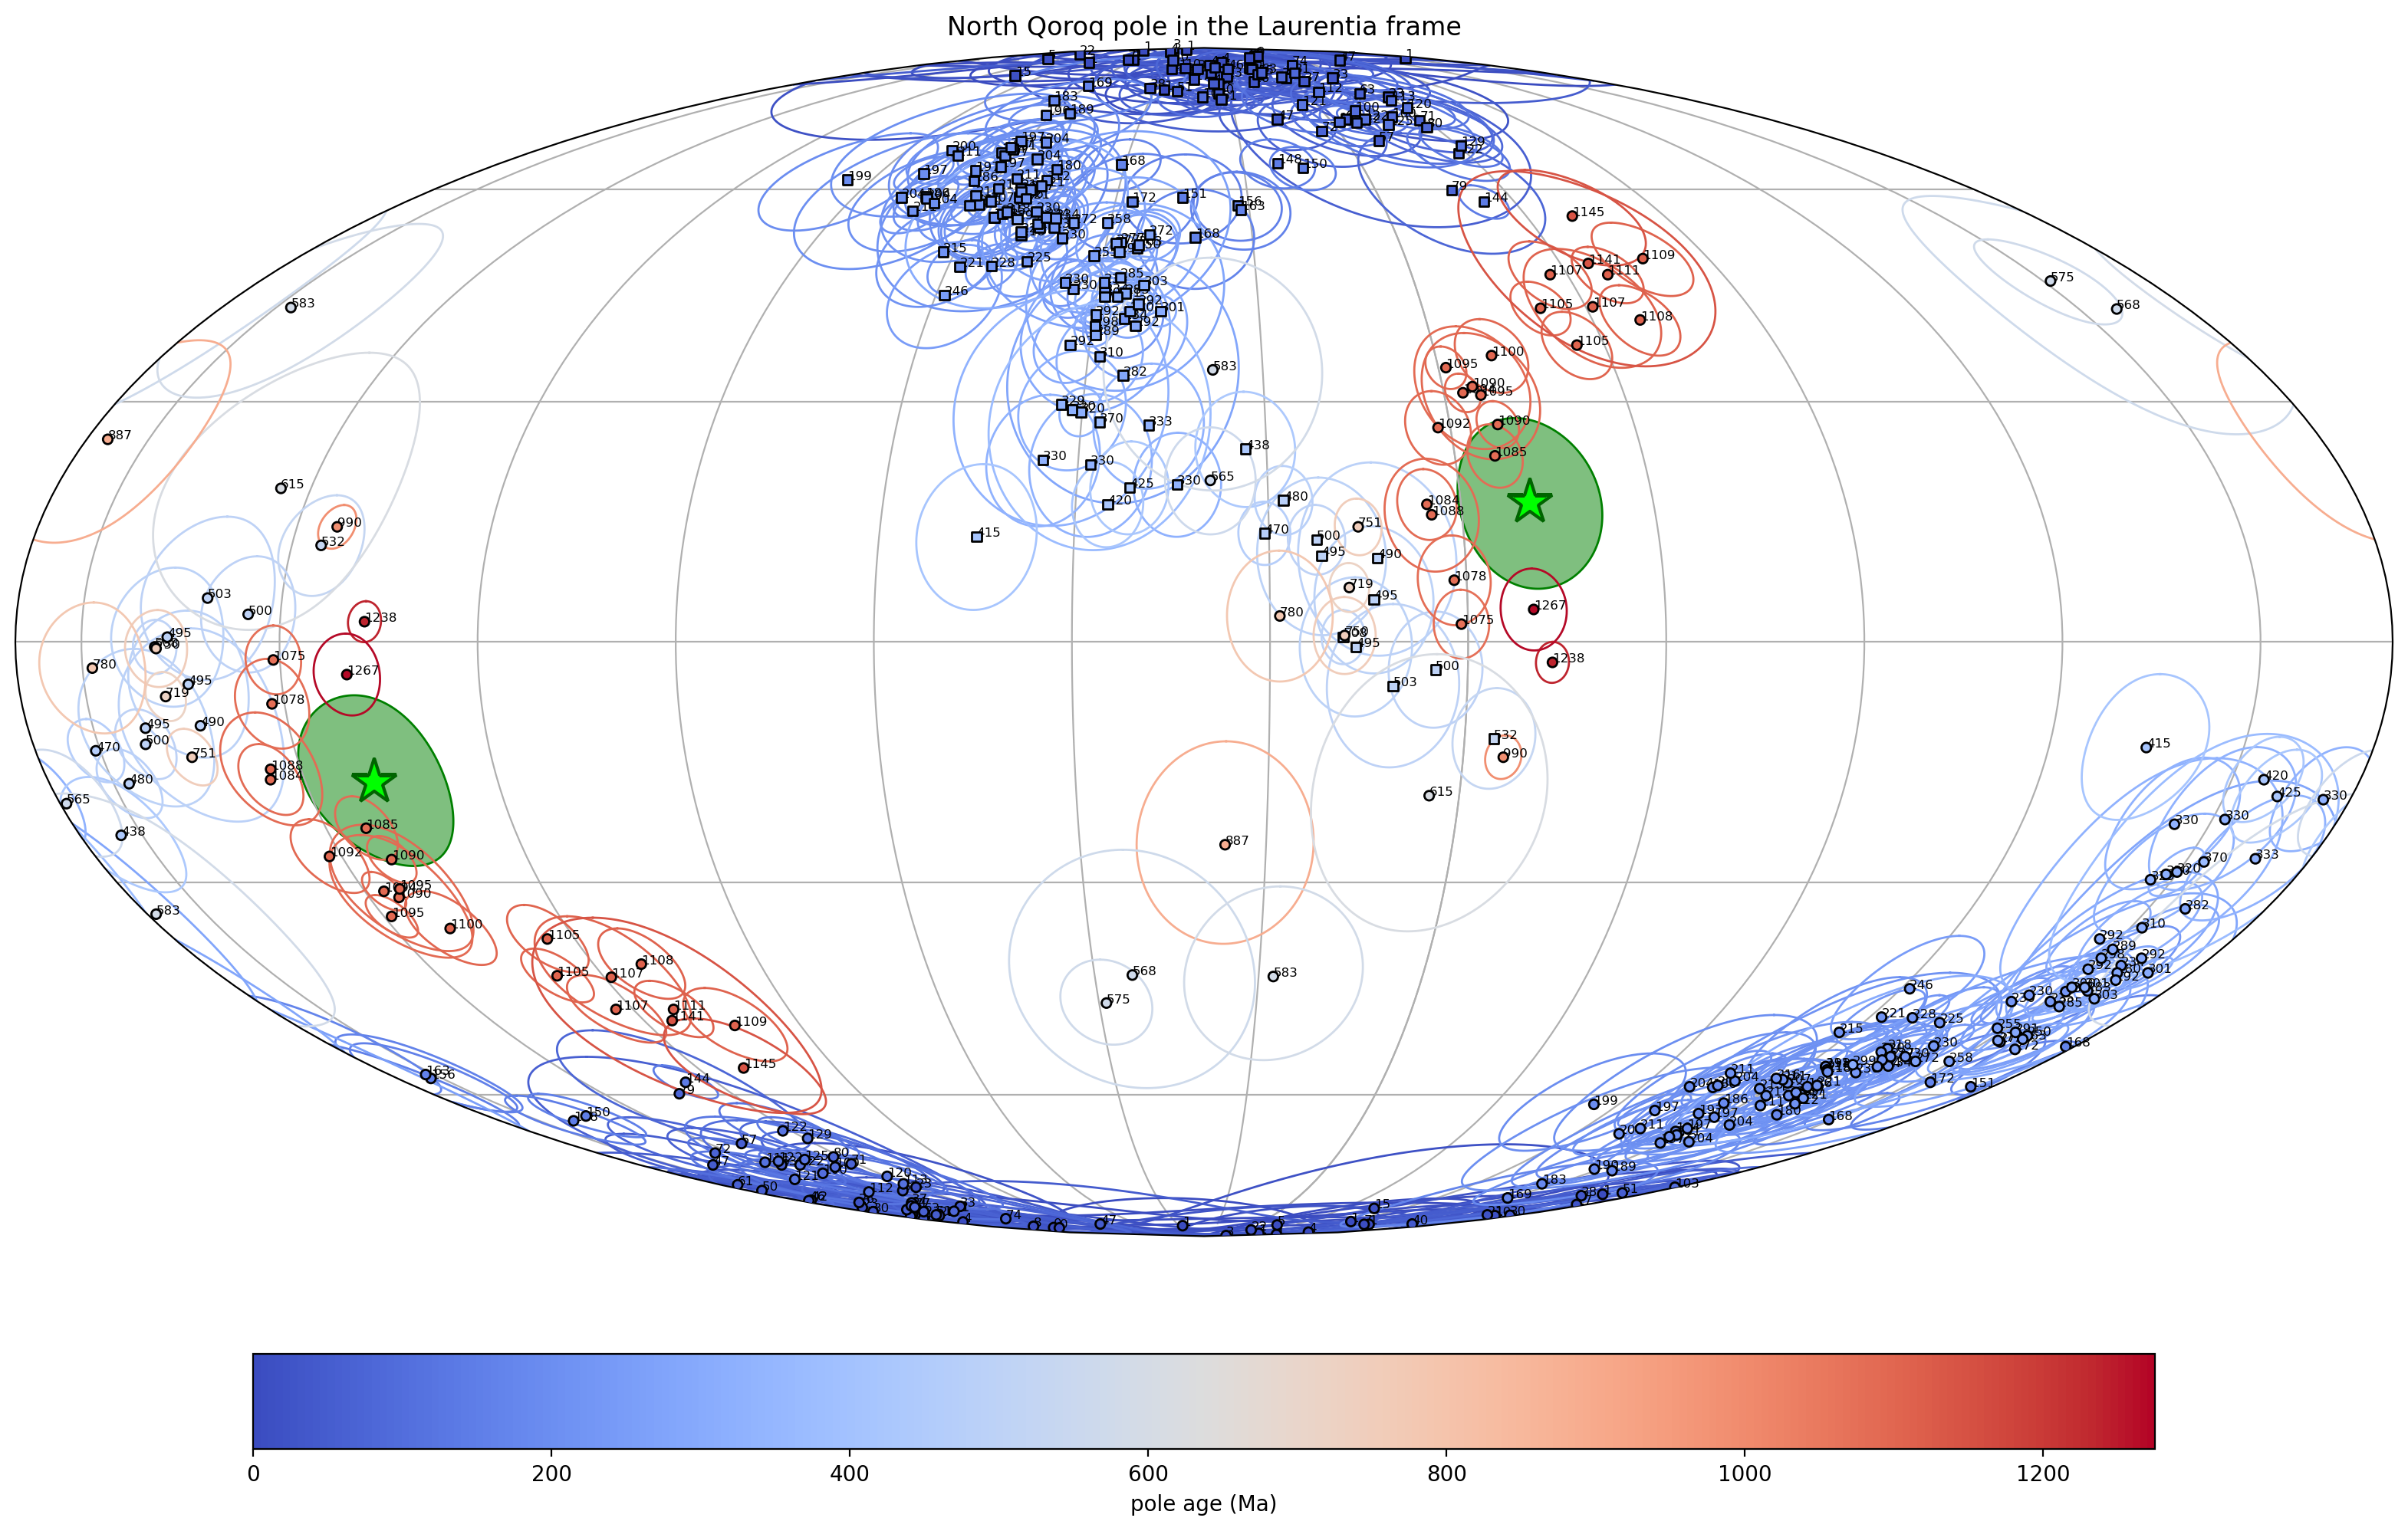

In [7]:
pt.plot_pole_overlap('North Qoroq Intrusion', Laurentia_stricto_poles, pt.Torsvik2012_Laurentia,
                     pole_plat=pole_rot['inc'], pole_plon=pole_rot['dec'],
                     pole_A95=pole_rot['alpha95'], pole_age=1275, show=False)
plt.title('North Qoroq pole in the Laurentia frame')
plt.show()

## Nordic workshop summary

The exported pole is the recalculated site-VGP Fisher mean in present-day Greenland coordinates. The comment records the handling of excluded rows and the direction-derived comparison with Piper (1992) and Evans et al. (2021).

In [8]:
summary = pt.make_nordic_summary(
    terrane='Laurentia-Greenland',
    rockname='North Qoroq Intrusion',
    sites=sites,
    dir_mean=dir_mean,
    pole_mean=pole_mean,
    study_lon=study_lon,
    study_lat=study_lat,
    component_comment='Characteristic remanent magnetization; North Qoroq intrusion site means (Gardar Province, South Greenland)',
    tests='',
    gpmdb_number='',
    magic_id='',
    percent_reversed='',
    demag_code='',
    R1=1, R2=int(r2_result['R2']), R3=1, R4='', R5=0, R6=1, R7=1, Grade='B', Grade_E21='B',
    nominal_age=1275, lomagage=1274, himagage=1276,
    REF_method='1275.3 +/- 1.1 Ma U-Pb date (2 sigma) from Upton (2003) on the adjacent Motzfeldt complex; Upton et al. (2003) interpreted this date to support a previous 1268 +/- 60 Ma Rb-Sr date from North Qoroq.',
    POLE_AUTHORS='Piper, J.D.A.',
    YEAR=1992,
    JOURNAL='Precambrian Res.',
    VOLUME='54',
    VPAGES='153-172',
    TITLE='The palaeomagnetism of major (Middle Proterozoic) igneous complexes, South Greenland and the Gardar apparent polar wander track',
    COMMENT='Recalculated from the twelve included Piper (1992) Table 3 North Qoroq site means; site 25 and component 37(a) are excluded as in the source group mean. Site VGP Fisher pole is %.1f N / %.1f E, A95 %.1f. The direction-derived pole from the polarity-unified mean is %.1f N / %.1f E, dp/dm %.1f/%.1f, matching the Piper/Evans pole within rounding.' % (pole_mean['inc'], pole_mean['dec'], pole_mean['alpha95'], dir_pole['inc'], dir_pole['dec'], dir_pole['dp'], dir_pole['dm'])
)
pt.save_nordic_summary(summary, '1275_North_Qoroq')
summary

,Terrane,ROCKNAME,RESULT#,COMPONENT,TESTS,TILT,SLAT,SLONG,B,N,...,himagage,REF/method,ROCKNAME,POLE AUTHORS,YEAR,JOURNAL,VOLUME,VPAGES,TITLE,Comment
0,Laurentia-Greenland,North Qoroq Intrusion,,Characteristic remanent magnetization; North Q...,,0,61.2,314.6,12,65,...,1276,1275.3 +/- 1.1 Ma U-Pb date (2 sigma) from Upt...,North Qoroq Intrusion,"Piper, J.D.A.",1992,Precambrian Res.,54,153-172,The palaeomagnetism of major (Middle Proterozo...,Recalculated from the twelve included Piper (1...
